# What if we just have endpoint data

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
from scipy.optimize import minimize
import ima_takeda as tkd

In [3]:
df = pd.read_csv("data/endpoint_data.csv")

## With ODE


=== Best Shared Parameters ===
k_on   = 0.000100
k_off  = 1.000000
k_kill = 0.001000
g      = 0.011117
Avg % Squared Error = 275.49%
      T_0       T_N     E_0     T_sim  % Error
0    5000   2632.31  100000    482.31   -43.00
1    5000   3101.24   50000   1015.17   -41.72
2    5000   3600.15   25000   2175.55   -28.49
3    5000   4494.88   12500   4470.68    -0.48
4    5000   6214.18    6250   7678.38    29.28
5    5000   7800.80    3125  10517.15    54.33
6   10000   4256.89  200000    479.94   -37.77
7   10000   4410.46  100000   1014.21   -33.96
8   10000   5217.99   50000   2250.96   -29.67
9   10000   4604.13   25000   5296.14     6.92
10  10000   7591.93   12500  11440.07    38.48
11  10000  11846.69    6250  18394.56    65.48
12  20000  16949.06  400000    478.19   -82.35
13  20000  19223.19  200000   1009.15   -91.07
14  20000  18082.07  100000   2257.06   -79.13
15  20000  18228.82   50000   5704.98   -62.62
16  20000  19431.79   25000  15902.35   -17.65
17  20000  23895.15 

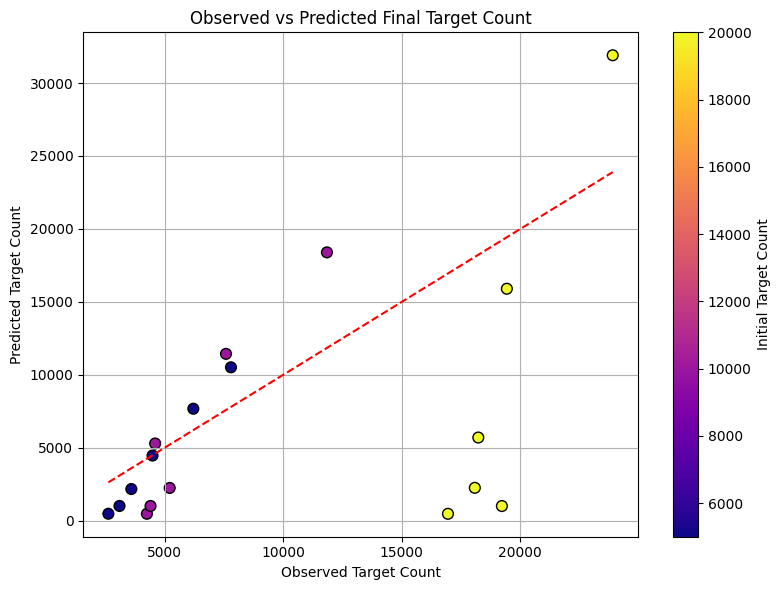

In [4]:
# Time setup
t_span = (0, 96)
t_eval = [96]


# ODE system
def ode_system(t, z, params):
    k_on, k_off, k_kill, g = params
    T, E, C = z
    dTdt = g * T - k_on * E * T + k_off * C
    dEdt = -k_on * E * T + k_off * C + k_kill * C
    dCdt = k_on * E * T - k_off * C - k_kill * C
    return [dTdt, dEdt, dCdt]


# Simulate final T value only
def simulate_T_final(E_0, T_0, params):
    z0 = [T_0, E_0, 0.0]
    sol = solve_ivp(lambda t, z: ode_system(t, z, params), t_span, z0, t_eval=t_eval, method="RK45")
    return sol.y[0, -1]  # Final T


# Loss function: average squared percentage error
def final_only_loss_weighted(param_array):
    if np.any(np.array(param_array) < 0):
        return np.inf

    errors = []
    for _, row in df.iterrows():
        T_sim = simulate_T_final(row["E_0"], row["T_0"], param_array)
        perc_error_sq = ((T_sim - row["T_N"]) / row["T_0"]) ** 2
        et_ratio = row["E_0"] / row["T_0"]
        weight = et_ratio**1.5  # or np.log1p(et_ratio), or et_ratio**alpha
        errors.append(weight * perc_error_sq)

    return np.mean(errors)


# Initial guess and bounds
initial_guess = [0.0003, 0.3, 0.007, 0.007]
bounds = [(0.0001, 0.001), (0, 1), (0.001, 0.02), (0.001, 0.02)]

# Fit parameters
res = minimize(final_only_loss_weighted, x0=initial_guess, bounds=bounds, method="L-BFGS-B")
best_params = res.x
k_on, k_off, k_kill, g = best_params

# Simulate and store results
T_sim_list = []
for _, row in df.iterrows():
    T_sim = simulate_T_final(row["E_0"], row["T_0"], best_params)
    T_sim_list.append(T_sim)

df["T_sim"] = T_sim_list
df["% Error"] = 100 * (df["T_sim"] - df["T_N"]) / df["T_0"]

# Print best parameters and preview df
print(f"\n=== Best Shared Parameters ===")
print(f"k_on   = {k_on:.6f}")
print(f"k_off  = {k_off:.6f}")
print(f"k_kill = {k_kill:.6f}")
print(f"g      = {g:.6f}")
print(f"Avg % Squared Error = {100 * np.sqrt(res.fun):.2f}%")
print(df.round(2))

# Optional plot
plt.figure(figsize=(8, 6))
plt.scatter(df["T_N"], df["T_sim"], c=df["T_0"], cmap="plasma", s=60, edgecolor="k")
plt.plot([df["T_N"].min(), df["T_N"].max()], [df["T_N"].min(), df["T_N"].max()], "r--")
plt.xlabel("Observed Target Count")
plt.ylabel("Predicted Target Count")
plt.title("Observed vs Predicted Final Target Count")
plt.colorbar(label="Initial Target Count")
plt.grid(True)
plt.tight_layout()
plt.show()

## With ABM


=== Best ABM-Fitted Parameters ===
k_on   = 0.400000
k_off  = 0.300000
k_kill = 0.007000
g      = 0.007000
Avg % Squared Error = 245.08%
       E_0    T_0       T_N  T_sim_abm  % Error ABM
0   100000   5000   2632.31        819       -36.27
1    50000   5000   3101.24        873       -44.56
2    25000   5000   3600.15        801       -55.98
3    12500   5000   4494.88        861       -72.68
4     6250   5000   6214.18        838      -107.52
5     3125   5000   7800.80       4534       -65.34
6   200000  10000   4256.89       1617       -26.40
7   100000  10000   4410.46       1629       -27.81
8    50000  10000   5217.99       1668       -35.50
9    25000  10000   4604.13       1629       -29.75
10   12500  10000   7591.93       1692       -59.00
11    6250  10000  11846.69       9221       -26.26
12  400000  20000  16949.06       3200       -68.75
13  200000  20000  19223.19       3238       -79.93
14  100000  20000  18082.07       3330       -73.76
15   50000  20000  18228.82   

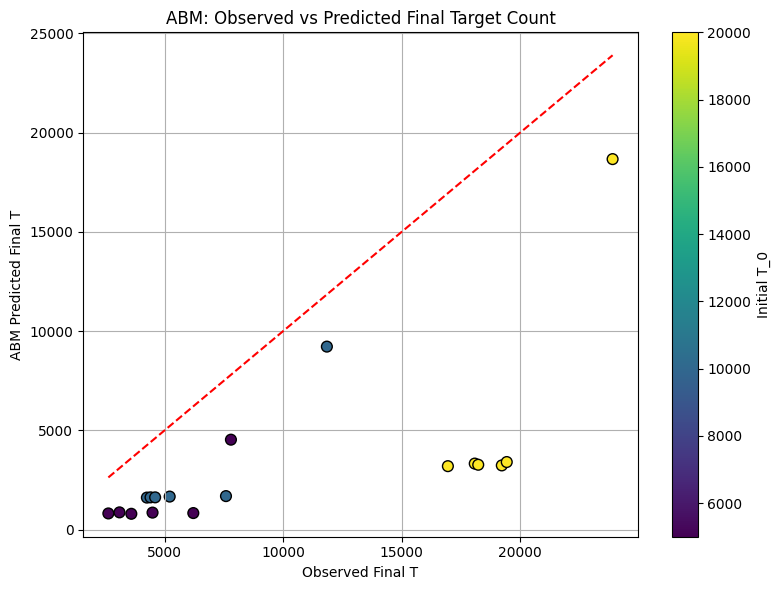

In [5]:
def run_abm(E_0, T_0, k_on, k_off, k_kill, g, seed=42):
    sim = tkd.WellSimulation(
        E_0=int(E_0),
        T_0=int(T_0),
        r=0.02,
        m=0.02,
        N=96,
        L=1.0,
        k_on=k_on,
        k_off=k_off,
        k_kill=k_kill,
        g_E=0,
        g_T=g,
        early_stop=(False, 10, 0.0),
        log_all=False,
        use_tqdm=False,
        seed=seed,
    )
    sim.run()
    T_final = sim.history["T"][-1]
    return T_final


# ABM simulation function (replace this with your actual implementation)
def simulate_T_final_abm(E_0, T_0, params, seed=42):
    k_on, k_off, k_kill, g = params
    # Insert your ABM call here
    T_final = run_abm(E_0, T_0, k_on, k_off, k_kill, g, seed=seed)
    return T_final


# Loss function for ABM (same structure, different simulator)
def final_only_loss_weighted_abm(param_array):
    if np.any(np.array(param_array) < 0):
        return np.inf

    errors = []
    for i, row in df.iterrows():
        T_sim = simulate_T_final_abm(row["E_0"], row["T_0"], param_array, seed=100 + i)  # pyright: ignore[reportOperatorIssue]
        perc_error_sq = ((T_sim - row["T_N"]) / row["T_0"]) ** 2
        et_ratio = row["E_0"] / row["T_0"]
        weight = et_ratio**1.5  # or any other scheme
        errors.append(weight * perc_error_sq)

    return np.mean(errors)


# Initial guess and bounds
initial_guess = [0.4, 0.3, 0.007, 0.007]
bounds = [(0.2, 0.6), (0.1, 0.5), (0.001, 0.02), (0.007, 0.007)]

# Fit using ABM
res_abm = minimize(final_only_loss_weighted_abm, x0=initial_guess, bounds=bounds, method="L-BFGS-B")
best_params_abm = res_abm.x
k_on, k_off, k_kill, g = best_params_abm

# Simulate and store ABM results
T_sim_list = []
for i, row in df.iterrows():
    T_sim = simulate_T_final_abm(row["E_0"], row["T_0"], best_params_abm, seed=100 + i)  # pyright: ignore[reportOperatorIssue]
    T_sim_list.append(T_sim)

df["T_sim_abm"] = T_sim_list
df["% Error ABM"] = 100 * (df["T_sim_abm"] - df["T_N"]) / df["T_0"]

# Print results
print(f"\n=== Best ABM-Fitted Parameters ===")
print(f"k_on   = {k_on:.6f}")
print(f"k_off  = {k_off:.6f}")
print(f"k_kill = {k_kill:.6f}")
print(f"g      = {g:.6f}")
print(f"Avg % Squared Error = {100 * np.sqrt(res_abm.fun):.2f}%")
print(df[["E_0", "T_0", "T_N", "T_sim_abm", "% Error ABM"]].round(2))

# Optional plot
plt.figure(figsize=(8, 6))
plt.scatter(df["T_N"], df["T_sim_abm"], c=df["T_0"], cmap="viridis", s=60, edgecolor="k")
plt.plot([df["T_N"].min(), df["T_N"].max()], [df["T_N"].min(), df["T_N"].max()], "r--")
plt.xlabel("Observed Final T")
plt.ylabel("ABM Predicted Final T")
plt.title("ABM: Observed vs Predicted Final Target Count")
plt.colorbar(label="Initial T_0")
plt.grid(True)
plt.tight_layout()
plt.show()